# 01.9 — Synthesis: Mini Data Analysis Project

**Phase:** 01 — Python Foundations

**Status:** VERIFIED

---

## 1. What Are We Solving?

This unit ties together everything from Phase 01: Python basics, data structures, functions, OOP, NumPy, Pandas, Matplotlib, and file I/O. You'll build a **mini data analysis project** end-to-end.

## 2. Why Does This Matter?

This is your first taste of a real ML-style workflow: generate/load data → clean it → explore it → visualize it → draw conclusions. This is the pattern you'll repeat for every project.

## 3. Prerequisites

- Units 01.1 through 01.8

## 4. Learning Objectives

By the end of this notebook, you should be able to:
- Combine all Phase 01 skills in one project
- Build a reusable data-analysis pipeline
- Use OOP to structure a small analysis tool
- Draw conclusions from data

## 5. The Project

**Scenario:** You're a data analyst at a company. You have data on employees (age, salary, department, years of experience). Your job is to:

1. Generate a realistic dataset.
2. Clean it (handle missing values).
3. Explore it (summary statistics).
4. Visualize it (plots).
5. Answer business questions.

Let's build this step by step.

## 6. Step 1: Generate the Dataset

We'll create a realistic employee dataset with some missing values.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

np.random.seed(42)

n = 200
departments = ["Engineering", "Sales", "Marketing", "HR", "Finance"]

data = {
    "employee_id": range(1, n + 1),
    "department": np.random.choice(departments, n, p=[0.3, 0.25, 0.2, 0.1, 0.15]),
    "age": np.random.randint(22, 60, n),
    "years_experience": np.random.randint(0, 35, n),
    "salary": np.random.randint(30000, 150000, n),
}

df = pd.DataFrame(data)

# Introduce some missing values
df.loc[df.sample(10, random_state=1).index, "salary"] = np.nan
df.loc[df.sample(8, random_state=2).index, "age"] = np.nan

print(f"Dataset shape: {df.shape}")
print(df.head())

Dataset shape: (200, 5)
   employee_id   department   age  years_experience    salary
0            1        Sales  45.0                28  122234.0
1            2      Finance  32.0                25   83682.0
2            3    Marketing  29.0                 9   89494.0
3            4    Marketing  57.0                25  111317.0
4            5  Engineering  59.0                33       NaN


## 7. Step 2: Clean the Data

Handle missing values. We'll fill missing salaries with the median and missing ages with the mean.

In [2]:
# Clean the data
print("Missing values before cleaning:")
print(df.isnull().sum())

# Fill missing salary with median
df["salary"] = df["salary"].fillna(df["salary"].median())

# Fill missing age with mean
df["age"] = df["age"].fillna(df["age"].mean().round())

print("\nMissing values after cleaning:")
print(df.isnull().sum())
print("\nData is clean!")

Missing values before cleaning:
employee_id          0
department           0
age                  8
years_experience     0
salary              10
dtype: int64

Missing values after cleaning:
employee_id         0
department          0
age                 0
years_experience    0
salary              0
dtype: int64

Data is clean!


## 8. Step 3: Explore the Data

Compute summary statistics and understand the data.

In [3]:
# Explore the data
print("Summary statistics:")
print(df.describe())

print("\nEmployees per department:")
print(df["department"].value_counts())

print("\nAverage salary by department:")
print(df.groupby("department")["salary"].mean().round(0))

Summary statistics:
       employee_id       age  years_experience         salary
count   200.000000  200.0000        200.000000     200.000000
mean    100.500000   42.1300         17.170000   90728.870000
std      57.879185   10.9054         10.003572   35651.239625
min       1.000000   22.0000          0.000000   30055.000000
25%      50.750000   33.0000          9.000000   57037.750000
50%     100.500000   43.0000         17.000000   92433.500000
75%     150.250000   51.0000         26.000000  117561.500000
max     200.000000   59.0000         34.000000  149803.000000

Employees per department:
department
Engineering    66
Sales          50
Marketing      33
Finance        31
HR             20
Name: count, dtype: int64

Average salary by department:
department
Engineering    89061.0
Finance        92759.0
HR             78182.0
Marketing      94410.0
Sales          94261.0
Name: salary, dtype: float64


## 9. Step 4: Visualize the Data

Create plots to understand the data visually.

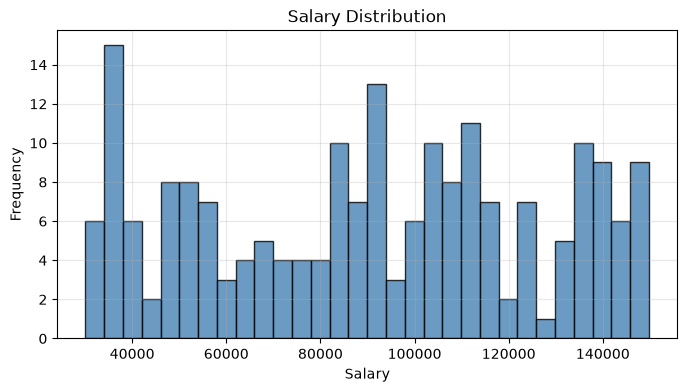

In [4]:
# Visualize: salary distribution
plt.figure(figsize=(8, 4))
plt.hist(df["salary"], bins=30, color="steelblue", edgecolor="black", alpha=0.8)
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.title("Salary Distribution")
plt.grid(True, alpha=0.3)
plt.show()

<Figure size 800x400 with 0 Axes>

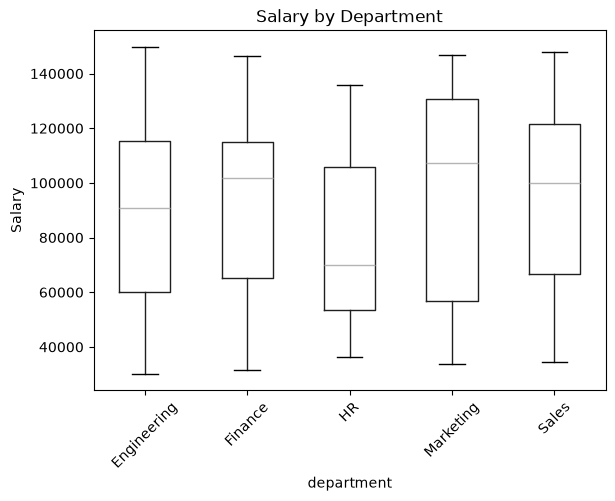

In [5]:
# Visualize: salary by department
dept_order = df.groupby("department")["salary"].mean().sort_values(ascending=False).index

plt.figure(figsize=(8, 4))
df.boxplot(column="salary", by="department", grid=False)
plt.title("Salary by Department")
plt.suptitle("")
plt.ylabel("Salary")
plt.xticks(rotation=45)
plt.show()

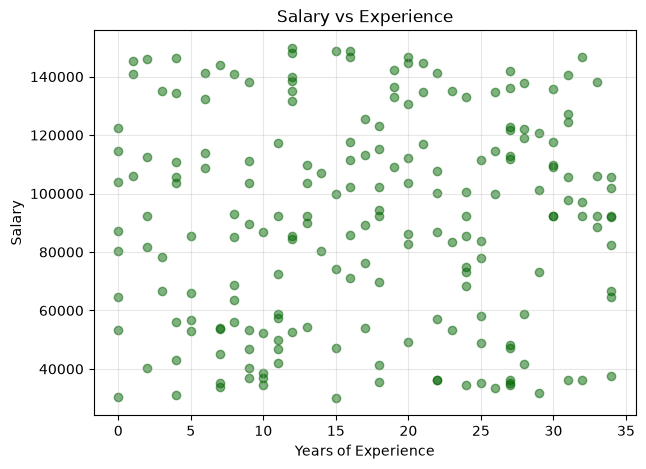

In [6]:
# Visualize: salary vs experience
plt.figure(figsize=(7, 5))
plt.scatter(df["years_experience"], df["salary"], alpha=0.5, color="darkgreen")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary vs Experience")
plt.grid(True, alpha=0.3)
plt.show()

## 10. Step 5: Answer Business Questions

Use the data to answer real questions.

In [7]:
# Answer business questions

# Q1: Which department has the highest average salary?
avg_salary = df.groupby("department")["salary"].mean()
top_dept = avg_salary.idxmax()
print(f"Q1: Highest average salary is in {top_dept} (${avg_salary[top_dept]:,.0f})")

# Q2: What's the correlation between experience and salary?
corr = df["years_experience"].corr(df["salary"])
print(f"Q2: Correlation between experience and salary: {corr:.3f}")

# Q3: What's the average age of employees?
avg_age = df["age"].mean()
print(f"Q3: Average employee age: {avg_age:.1f}")

# Q4: How many employees earn more than $100k?
high_earners = (df["salary"] > 100000).sum()
print(f"Q4: Employees earning > $100k: {high_earners}")

# Q5: Which department has the most employees?
largest_dept = df["department"].value_counts().idxmax()
print(f"Q5: Largest department: {largest_dept}")

Q1: Highest average salary is in Marketing ($94,410)
Q2: Correlation between experience and salary: 0.057
Q3: Average employee age: 42.1
Q4: Employees earning > $100k: 89
Q5: Largest department: Engineering


## 11. Step 6: Build a Reusable Analysis Class

Let's wrap the analysis into a reusable OOP class — the pattern you'll use for real projects.

In [8]:
# Reusable analysis class
class EmployeeAnalyzer:
    """Analyze employee data."""
    def __init__(self, df):
        self.df = df.copy()

    def clean(self):
        """Handle missing values."""
        self.df["salary"] = self.df["salary"].fillna(self.df["salary"].median())
        self.df["age"] = self.df["age"].fillna(self.df["age"].mean().round())
        return self

    def avg_salary_by_dept(self):
        return self.df.groupby("department")["salary"].mean().sort_values(ascending=False)

    def top_department(self):
        avg = self.avg_salary_by_dept()
        return avg.idxmax(), avg.max()

    def summary(self):
        return {
            "rows": len(self.df),
            "avg_age": self.df["age"].mean(),
            "avg_salary": self.df["salary"].mean(),
            "top_dept": self.top_department()[0],
        }

# Use the class
analyzer = EmployeeAnalyzer(df).clean()
print("Average salary by department:")
print(analyzer.avg_salary_by_dept().round(0))
print("\nSummary:")
print(analyzer.summary())

Average salary by department:
department
Marketing      94410.0
Sales          94261.0
Finance        92759.0
Engineering    89061.0
HR             78182.0
Name: salary, dtype: float64

Summary:
{'rows': 200, 'avg_age': np.float64(42.13), 'avg_salary': np.float64(90728.87), 'top_dept': 'Marketing'}


## 12. Step 7: Save the Cleaned Data

Persist the cleaned dataset for future use.

In [9]:
# Save cleaned data
csv_dir = os.path.join("datasets", "processed")
os.makedirs(csv_dir, exist_ok=True)
out_path = os.path.join(csv_dir, "employees_clean.csv")

df.to_csv(out_path, index=False)
print(f"Saved cleaned data to {out_path}")
print(f"File exists: {os.path.exists(out_path)}")

# Clean up (this is a demo; in a real project you'd keep the file)
os.remove(out_path)
print("Cleaned up demo file.")

Saved cleaned data to datasets\processed\employees_clean.csv
File exists: True
Cleaned up demo file.


## 13. Failure Case: Data Leakage in Cleaning

A subtle but important bug: computing the median/mean on the **full** dataset (including the values you'll later use for testing) can leak information. In real ML, you must compute statistics on the **training set only**. We'll cover this in detail in Phase 04, but it's worth noting now.

In [10]:
# Note on data leakage (conceptual)
print("""
IMPORTANT: In real ML, when you split data into train/test,
you must compute fill values (median, mean) on the TRAINING set
only, then apply them to the test set. Otherwise you leak
information from the test set into training.

We'll cover this properly in Phase 04 (Data Preparation).
""")


IMPORTANT: In real ML, when you split data into train/test,
you must compute fill values (median, mean) on the TRAINING set
only, then apply them to the test set. Otherwise you leak
information from the test set into training.

We'll cover this properly in Phase 04 (Data Preparation).



## 14. Debugging: Common Errors in This Workflow

- **NaN propagation**: forgetting to clean missing values before computing stats.
- **dtype issues**: mixing int and float columns.
- **Groupby key errors**: column name typos.
- **Plot not showing**: forgetting `plt.show()`.
- **Path errors**: relative paths depend on working directory.

## 15. Real-World Considerations

- **Reproducibility**: set `np.random.seed()` for consistent results.
- **Documentation**: document your analysis steps.
- **Version control**: commit your analysis code.
- **Reusable code**: wrap analysis in functions/classes.
- **Data quality**: always check for missing values and outliers.

## 16. Common Mistakes

- Not cleaning data before analysis
- Data leakage in train/test split
- Hard-coding paths
- Not setting random seeds
- Drawing conclusions from small samples

## 17. When NOT to Use

- Don't over-engineer a simple analysis with too many classes.
- Don't skip EDA — always explore before modeling.

## 18. Challenge

Extend the analysis: create a new column `salary_per_year` = `salary / years_experience` (handle division by zero), then find the department with the highest average `salary_per_year`.

In [11]:
# Challenge: salary per year of experience
df2 = df.copy()

# Handle division by zero (years_experience = 0)
df2["salary_per_year"] = df2.apply(
    lambda row: row["salary"] / row["years_experience"] if row["years_experience"] > 0 else np.nan,
    axis=1
)

# Department with highest avg salary_per_year
avg_spy = df2.groupby("department")["salary_per_year"].mean()
top = avg_spy.idxmax()
print(f"Department with highest salary-per-year: {top} (${avg_spy[top]:,.0f}/yr)")
print("\nAll departments:")
print(avg_spy.round(0).sort_values(ascending=False))

Department with highest salary-per-year: HR ($12,629/yr)

All departments:
department
HR             12629.0
Sales          11610.0
Engineering    10258.0
Finance         8707.0
Marketing       6600.0
Name: salary_per_year, dtype: float64


## Hands-On Practice

### Level 1: Basic
- Review: write a script that loads CSV, filters rows, computes stats

### Level 2: Guided
- Build a data pipeline: load -> clean -> transform -> visualize -> save

### Level 3: Independent
- Choose a real dataset and perform end-to-end analysis

### Level 4: Realistic
- Build a reusable analysis module with classes and functions

### Level 5: Challenge
- Create a CLI tool that accepts a CSV and produces a report


## Knowledge Check

1. Walk through the full data pipeline: what steps come in what order?
2. What Python features help you write reusable, maintainable code?
3. When would you use a class vs a function for data processing?



## Exit Criteria

- [ ] Can combine Python, NumPy, Pandas, and Matplotlib in one project
- [ ] Can structure code with functions, classes, and modules
- [ ] Can load, clean, analyze, and visualize data end-to-end
- [ ] Completed Level 4+ practice



## Next Step

-> Phase 02: Mathematics for Machine Learning — the theoretical foundations.


## 19. Closed-Book Recall

Without looking back:

1. How do you fill missing values in a DataFrame?
2. How do you compute average salary by department?
3. What is data leakage and why is it bad?
4. How do you create a reusable analysis class?
5. Why set a random seed?

## 20. Teach-Back Questions

Explain to another person:

- What is the end-to-end data analysis workflow?
- Why is cleaning data important?
- What did you learn from the salary vs experience plot?

## 21. Summary

You've completed Phase 01! You built a full mini data-analysis project combining Python basics, data structures, functions, OOP, NumPy, Pandas, Matplotlib, and file I/O. This is the foundation for everything ahead.

## 22. Further Experiment

- Load a real dataset (e.g., from Kaggle) and repeat this workflow.
- Add more visualizations (heatmap of correlations).
- Build a simple linear regression on salary vs experience.

## 23. Verification Status

```
STATUS: VERIFIED
EXECUTION: PASS
DEPENDENCIES: numpy, pandas, matplotlib
OUTPUTS: PASS
LAST VERIFIED: 2026-08-28
```